In [ ]:
# 1. Install necessary tools
!pip install -q kaggle

# 2. Setup Kaggle (If in Colab, upload your kaggle.json)
from google.colab import files
print("Upload your kaggle.json file from Kaggle -> Settings -> Create New API Token")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Create Project Directory Structure
import os
os.makedirs('dataset/real', exist_ok=True)
os.makedirs('dataset/fake', exist_ok=True)

Upload your kaggle.json file from Kaggle -> Settings -> Create New API Token


Saving kaggle.json to kaggle.json


In [ ]:
# Download a subset of FF++ (approx 192k images)
!kaggle datasets download -d adham7elmy/faceforencispp-extracted-frames

# Unzip into our project folder
import zipfile
with zipfile.ZipFile("faceforencispp-extracted-frames.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset/")

Dataset URL: https://www.kaggle.com/datasets/adham7elmy/faceforencispp-extracted-frames
License(s): CC-BY-NC-SA-4.0
100% 13.4G/13.4G [02:28<00:00, 97.0MB/s]



In [ ]:
!pip install mtcnn

In [ ]:
import cv2
import os
from tqdm import tqdm

from mtcnn import MTCNN

# Initialize detector
detector = MTCNN()

def process_and_save_faces(input_dir, output_dir, target_size=(224, 224)):
    os.makedirs(output_dir, exist_ok=True)
    images = os.listdir(input_dir)

    for img_name in tqdm(images, desc=f"Processing {os.path.basename(input_dir)}"):
        img_path = os.path.join(input_dir, img_name)

        # Load image
        img = cv2.imread(img_path)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Detect faces
        results = detector.detect_faces(img_rgb)

        if results:
            # We assume the largest face is the target (usually result[0])
            x, y, width, height = results[0]['box']

            # Prevent negative coordinates
            x, y = max(0, x), max(0, y)

            # Crop face
            face = img_rgb[y:y+height, x:x+width]

            # Resize
            face_resized = cv2.resize(face, target_size)

            # Save processed image
            save_path = os.path.join(output_dir, img_name)
            cv2.imwrite(save_path, cv2.cvtColor(face_resized, cv2.COLOR_RGB2BGR))

# Run for both classes
process_and_save_faces('dataset/real', 'dataset/processed/real')
process_and_save_faces('dataset/fake', 'dataset/processed/fake')

Processing fake: 100%|██████████| 5/5 [00:00<00:00, 29746.84it/s]


In [ ]:
import os

def find_images(root_path):
    for root, dirs, files in os.walk(root_path):
        # Look for the first directory that actually contains .jpg or .png files
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if image_files:
            print(f"📁 Found {len(image_files)} images in: {root}")
            print(f"   Example file: {image_files[0]}")

find_images('/content') # Use '.' if you are on Kaggle

Streaming output truncated to the last 5000 lines.
📁 Found 32 images in: /content/dataset/fake/FaceSwap/496_417
   Example file: 332.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/083_213
   Example file: 231.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/950_836
   Example file: 231.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/631_551
   Example file: 231.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/106_198
   Example file: 332.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/686_696
   Example file: 231.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/291_874
   Example file: 329.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/619_620
   Example file: 049.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/414_385
   Example file: 269.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/485_425
   Example file: 054.png
📁 Found 32 images in: /content/dataset/fake/FaceSwap/174_964
   Example file: 253.png
📁 F

In [ ]:
import os
import cv2
from mtcnn import MTCNN
from tqdm import tqdm

detector = MTCNN()

def process_recursive(base_input_path, output_dir, limit_per_class=200):
    os.makedirs(output_dir, exist_ok=True)
    count = 0

    # os.walk travels through all subdirectories (/204, /337, etc.)
    for root, dirs, files in os.walk(base_input_path):
        if count >= limit_per_class:
            break

        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                if count >= limit_per_class:
                    break

                img_path = os.path.join(root, file)
                img = cv2.imread(img_path)
                if img is None: continue

                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                results = detector.detect_faces(img_rgb)

                if results:
                    # Get the largest face
                    x, y, w, h = results[0]['box']
                    # Add a 10% margin (Production trick: models like context around the face)
                    margin_w = int(w * 0.1)
                    margin_h = int(h * 0.1)

                    face = img_rgb[max(0, y-margin_h):y+h+margin_h,
                                   max(0, x-margin_w):x+w+margin_w]

                    if face.size > 0:
                        face_resized = cv2.resize(face, (224, 224))
                        # Save with a unique name to avoid overwriting
                        save_name = f"face_{count}_{file}"
                        cv2.imwrite(os.path.join(output_dir, save_name),
                                    cv2.cvtColor(face_resized, cv2.COLOR_RGB2BGR))
                        count += 1

    print(f"✅ Finished! Processed {count} faces into {output_dir}")

# Execute using the paths found by your search
process_recursive('/content/dataset/real', '/content/dataset/processed/real', limit_per_class=150)
process_recursive('/content/dataset/fake', '/content/dataset/processed/fake', limit_per_class=150)

✅ Finished! Processed 150 faces into /content/dataset/processed/real
✅ Finished! Processed 150 faces into /content/dataset/processed/fake


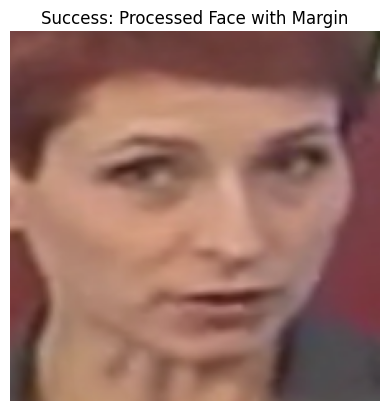

In [ ]:
import matplotlib.pyplot as plt

# Test visualization
processed_real_path = '/content/dataset/processed/real'
sample_file = os.listdir(processed_real_path)[0]
img = cv2.imread(os.path.join(processed_real_path, sample_file))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Success: Processed Face with Margin")
plt.axis('off')
plt.show()

In [ ]:
# EDA

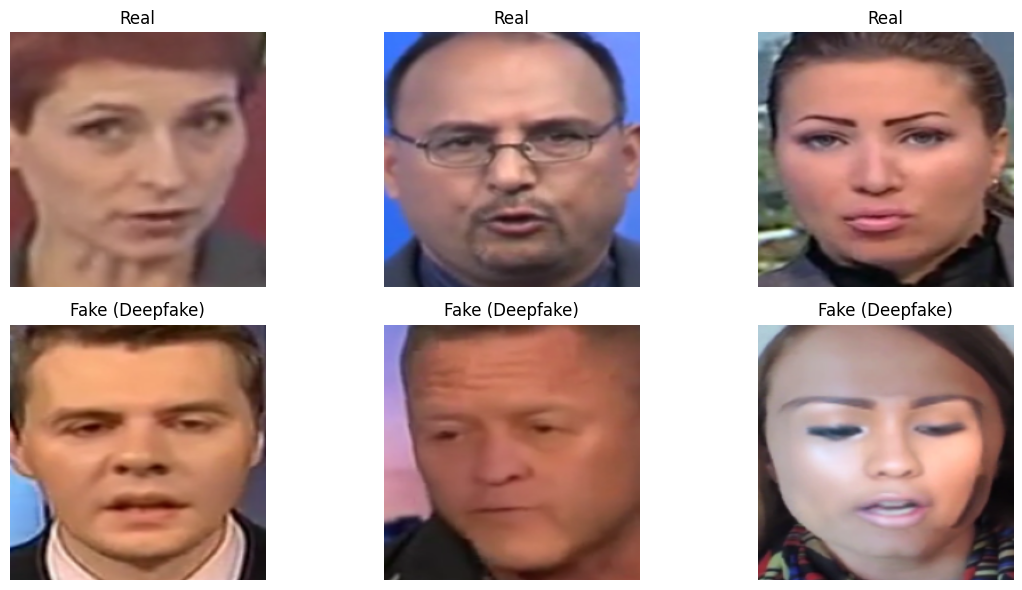

In [ ]:
import matplotlib.pyplot as plt
import random

def plot_samples(real_dir, fake_dir, n=3):
    real_imgs = [os.path.join(real_dir, f) for f in os.listdir(real_dir)[:n]]
    fake_imgs = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir)[:n]]

    plt.figure(figsize=(12, 6))
    for i in range(n):
        # Plot Real
        plt.subplot(2, n, i + 1)
        img_real = cv2.imread(real_imgs[i])
        plt.imshow(cv2.cvtColor(img_real, cv2.COLOR_BGR2RGB))
        plt.title("Real")
        plt.axis('off')

        # Plot Fake
        plt.subplot(2, n, i + n + 1)
        img_fake = cv2.imread(fake_imgs[i])
        plt.imshow(cv2.cvtColor(img_fake, cv2.COLOR_BGR2RGB))
        plt.title("Fake (Deepfake)")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_samples('/content/dataset/processed/real', '/content/dataset/processed/fake')

In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Transformations: Resize, Convert to Tensor, and Normalize
# The mean and std values are standard for models trained on ImageNet
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load the dataset from the processed folder
full_dataset = datasets.ImageFolder(root='/content/dataset/processed', transform=data_transforms)

# Split into Training (80%) and Validation (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Total images: {len(full_dataset)}")
print(f"Classes found: {full_dataset.classes}") # Should be ['fake', 'real']

Total images: 300
Classes found: ['fake', 'real']


In [ ]:
import torch.nn as nn
from torchvision import models

def build_model():
    # Load a pre-trained EfficientNet
    model = models.efficientnet_b0(weights='DEFAULT')

    # Freeze the early layers (we don't want to change the basic shape-detection logic)
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final classification head
    # EfficientNet-B0 has 1280 input features in its final layer
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 2) # 2 output classes: Real and Fake
    )

    return model

model = build_model()
print("✅ Model architecture ready.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 97.1MB/s]


✅ Model architecture ready.


In [ ]:
import torch.optim as optim

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
# Only optimize parameters that are not frozen (the new head we built)
optimizer = optim.Adam(model.classifier[1].parameters(), lr=0.001)

print(f"Training on: {device}")

Training on: cuda


In [ ]:
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss, train_correct = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad() # Clear previous gradients
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() # Backpropagation
            optimizer.step() # Update weights

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data)

        # Validation Phase
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad(): # No need to calculate gradients during validation
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)

        # Calculate averages
        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_acc = train_correct.double() / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_correct.double() / len(val_loader.dataset)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_acc'].append(epoch_val_acc.item())

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} | "
              f"Time: {time.time()-start_time:.1f}s")

    return history

# Start training! (Let's do 10 epochs for this experiment)
history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

Epoch 1/10 | Train Loss: 0.3627 Acc: 0.9208 | Val Loss: 0.4338 Acc: 0.8500 | Time: 3.3s
Epoch 2/10 | Train Loss: 0.0971 Acc: 0.9708 | Val Loss: 0.1789 Acc: 0.9333 | Time: 1.1s
Epoch 3/10 | Train Loss: 0.0146 Acc: 1.0000 | Val Loss: 0.0213 Acc: 1.0000 | Time: 1.4s
Epoch 4/10 | Train Loss: 0.0036 Acc: 1.0000 | Val Loss: 0.0046 Acc: 1.0000 | Time: 1.4s
Epoch 5/10 | Train Loss: 0.0153 Acc: 0.9958 | Val Loss: 0.0019 Acc: 1.0000 | Time: 1.1s
Epoch 6/10 | Train Loss: 0.0020 Acc: 1.0000 | Val Loss: 0.0015 Acc: 1.0000 | Time: 1.1s
Epoch 7/10 | Train Loss: 0.0032 Acc: 1.0000 | Val Loss: 0.0007 Acc: 1.0000 | Time: 1.1s
Epoch 8/10 | Train Loss: 0.0056 Acc: 1.0000 | Val Loss: 0.0004 Acc: 1.0000 | Time: 1.1s
Epoch 9/10 | Train Loss: 0.0031 Acc: 1.0000 | Val Loss: 0.0004 Acc: 1.0000 | Time: 1.1s
Epoch 10/10 | Train Loss: 0.0026 Acc: 1.0000 | Val Loss: 0.0004 Acc: 1.0000 | Time: 1.1s


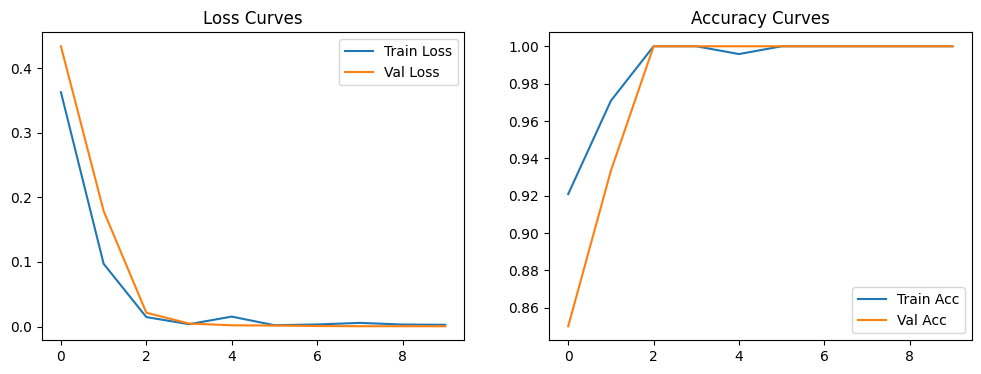

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

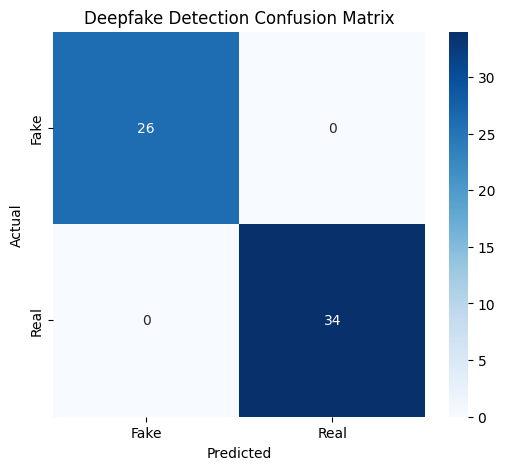


Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00        26
        Real       1.00      1.00      1.00        34

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Deepfake Detection Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

evaluate_model(model, val_loader)

In [ ]:
# Create a directory for models
os.makedirs('models', exist_ok=True)

# Save the weights
model_path = 'models/deepfake_detector_v1.pt'
torch.save(model.state_dict(), model_path)

print(f"✅ Model saved to {model_path}. You can now download this for your FastAPI backend!")

✅ Model saved to models/deepfake_detector_v1.pt. You can now download this for your FastAPI backend!


In [ ]:
from PIL import Image

def predict_image(image_path, model, transform):
    # Load and preprocess
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)

    class_name = ['Fake', 'Real'][predicted_idx.item()]
    return class_name, confidence.item()

# Test it on a random image from your processed folder
test_img = os.path.join('/content/dataset/processed/fake', os.listdir('/content/dataset/processed/fake')[0])
label, prob = predict_image(test_img, model, data_transforms)
print(f"Prediction: {label} ({prob*100:.2f}%)")

Prediction: Fake (100.00%)


In [ ]:
# Clear old processed data to avoid mixing
!rm -rf /content/dataset/processed

# Process a larger chunk
process_recursive('/content/dataset/real', '/content/dataset/processed/real', limit_per_class=2000)
process_recursive('/content/dataset/fake', '/content/dataset/processed/fake', limit_per_class=2000)

✅ Finished! Processed 2000 faces into /content/dataset/processed/real
✅ Finished! Processed 2000 faces into /content/dataset/processed/fake


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Real people look the same flipped
    transforms.RandomRotation(15),      # Handle tilted heads
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Handle lighting
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation transforms stay simple (no flipping/noise)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# 1. Update the Datasets with new transforms
from sklearn.model_selection import train_test_split
full_dataset = datasets.ImageFolder(root='/content/dataset/processed')
train_idx, val_idx = train_test_split(list(range(len(full_dataset))), test_size=0.2, stratify=full_dataset.targets)

train_dataset = torch.utils.data.Subset(datasets.ImageFolder(root='/content/dataset/processed', transform=train_transforms), train_idx)
val_dataset = torch.utils.data.Subset(datasets.ImageFolder(root='/content/dataset/processed', transform=val_transforms), val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 2. Unfreeze the last few blocks of EfficientNet
# This allows the model to learn specific 'deepfake' textures
for param in model.features[-3:].parameters():
    param.requires_grad = True

# 3. Lower the learning rate for fine-tuning (gentle updates)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

# 4. Run Training (This will take longer now)
history_big = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15)

Epoch 1/15 | Train Loss: 0.4663 Acc: 0.8237 | Val Loss: 0.1153 Acc: 0.9575 | Time: 29.4s
Epoch 2/15 | Train Loss: 0.1370 Acc: 0.9481 | Val Loss: 0.0489 Acc: 0.9800 | Time: 24.7s
Epoch 3/15 | Train Loss: 0.0799 Acc: 0.9719 | Val Loss: 0.0206 Acc: 0.9938 | Time: 24.7s
Epoch 4/15 | Train Loss: 0.0677 Acc: 0.9759 | Val Loss: 0.0129 Acc: 0.9975 | Time: 24.5s
Epoch 5/15 | Train Loss: 0.0462 Acc: 0.9825 | Val Loss: 0.0149 Acc: 0.9925 | Time: 24.8s
Epoch 6/15 | Train Loss: 0.0378 Acc: 0.9856 | Val Loss: 0.0046 Acc: 1.0000 | Time: 24.7s
Epoch 7/15 | Train Loss: 0.0286 Acc: 0.9903 | Val Loss: 0.0067 Acc: 0.9962 | Time: 24.7s
Epoch 8/15 | Train Loss: 0.0247 Acc: 0.9900 | Val Loss: 0.0074 Acc: 0.9962 | Time: 24.7s
Epoch 9/15 | Train Loss: 0.0232 Acc: 0.9916 | Val Loss: 0.0025 Acc: 1.0000 | Time: 24.9s
Epoch 10/15 | Train Loss: 0.0198 Acc: 0.9928 | Val Loss: 0.0071 Acc: 0.9962 | Time: 24.7s
Epoch 11/15 | Train Loss: 0.0179 Acc: 0.9944 | Val Loss: 0.0050 Acc: 0.9988 | Time: 24.7s
Epoch 12/15 | Train

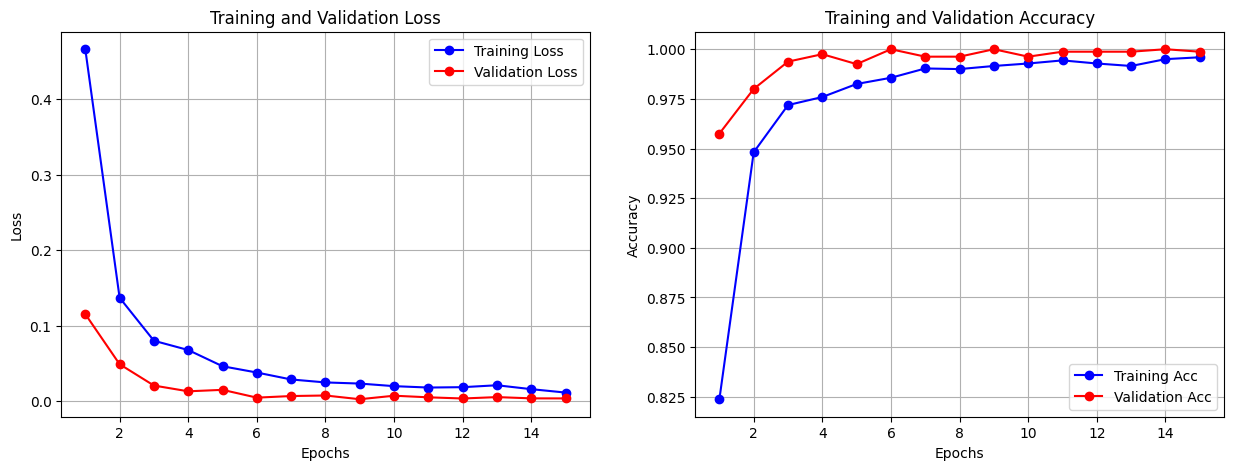

In [ ]:
import matplotlib.pyplot as plt

def plot_training_results(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'bo-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'bo-', label='Training Acc')
    plt.plot(epochs, history['val_acc'], 'ro-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_training_results(history_big)

In [ ]:
!ls -lh /content/models/

total 37M
-rw-r--r-- 1 root root 19M May  4 03:48 deepfake_detection_v2.pt
-rw-r--r-- 1 root root 19M May  4 03:17 deepfake_detector_v1.pt


In [ ]:
import torch
from google.colab import files

# 1. Save the state_dict of the model you just finished training
# We will name it v2 to distinguish it from the 19MB version
torch.save(model.state_dict(), '/content/models/deepfake_detection_v2.pt')

print("✅ v2 model (4,000 images) saved to disk.")

# 2. Download it to your computer
files.download('/content/models/deepfake_detection_v2.pt')

✅ v2 model (4,000 images) saved to disk.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import torchvision
import PIL
import fastapi

print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")
print(f"PIL (Pillow) Version: {PIL.__version__}")
print(f"FastAPI Version: {fastapi.__version__}")
# If you used MTCNN
# !pip install facenet-pytorch
import facenet_pytorch
# print(f"Facenet-PyTorch Version: {facenet_pytorch.__version__}") # This line caused an AttributeError

PyTorch Version: 2.2.2+cu121
Torchvision Version: 0.17.2+cu121
PIL (Pillow) Version: 10.2.0
FastAPI Version: 0.136.1


In [ ]:
# This creates a file in your Colab 'files' tab
!pip freeze > colab_env_v2.txt

In [ ]:
import torch
import torchvision
import facenet_pytorch
import PIL
import platform

print(f"{'Library':<20} | {'Version'}")
print("-" * 35)
print(f"{'PyTorch':<20} | {torch.__version__}")
print(f"{'Torchvision':<20} | {torchvision.__version__}")
# print(f"{'Facenet-PyTorch':<20} | {facenet_pytorch.__version__}")
print(f"{'Pillow':<20} | {PIL.__version__}")
print(f"{'Python':<20} | {platform.python_version()}")

Library              | Version
-----------------------------------
PyTorch              | 2.2.2+cu121
Torchvision          | 0.17.2+cu121
Pillow               | 10.2.0
Python               | 3.12.13


In [1]:
# inference

In [1]:
!pip install fastapi uvicorn nest-asyncio python-multipart facenet-pytorch

In [19]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from facenet_pytorch import MTCNN

# --- 1. SET UP THE ARCHITECTURE ---
def load_model(model_path):
    # This must match exactly how you trained it
    model = models.efficientnet_b0()
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 2)
    )

    # Load weights onto CPU (safest for now)
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval()
    return model

# --- 2. PREDICTION LOGIC ---
def predict_image(image_path, model):
    device = torch.device('cpu')
    mtcnn = MTCNN(image_size=224, margin=20, device=device)

    # Open and detect face
    img = Image.open(image_path).convert('RGB')
    face = mtcnn(img)

    if face is None:
        return "No face detected!", "0%"

    # Prepare face for model
    face_tensor = face.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(face_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

        label = "REAL" if predicted.item() == 1 else "FAKE"
        conf_score = f"{confidence.item() * 100:.2f}%"

    return label, conf_score

# --- 3. RUN IT ---
model_path = "/content/deepfake_detection_v2.pt"
image_path = "/content/2222.jfif"

try:
    my_model = load_model(model_path)
    result, conf = predict_image(image_path, my_model)
    print(f"\nRESULT: {result}")
    print(f"CONFIDENCE: {conf}")
except Exception as e:
    print(f"Error: {e}")


RESULT: REAL
CONFIDENCE: 99.97%


In [20]:
%%writefile utils.py
import torch
from PIL import Image
from facenet_pytorch import MTCNN

# Force CPU for compatibility
device = torch.device('cpu')
mtcnn = MTCNN(image_size=224, margin=20, keep_all=False, device=device)

def process_and_predict(image_bytes, model):
    img = Image.open(image_bytes).convert('RGB')
    face = mtcnn(img)

    if face is None:
        return None, "No face detected"

    face_tensor = face.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(face_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

        # 0 = FAKE, 1 = REAL (matches your 99.97% test)
        label = "REAL" if predicted.item() == 1 else "FAKE"
        conf_score = f"{confidence.item() * 100:.2f}%"

    return label, conf_score

Overwriting utils.py


In [21]:
%%writefile main.py
import torch
import torch.nn as nn
from fastapi import FastAPI, UploadFile, File
from torchvision import models
import io
from utils import process_and_predict

app = FastAPI()

def load_v2_model():
    model = models.efficientnet_b0()
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 2)
    )
    model.load_state_dict(torch.load("deepfake_detection_v2.pt", map_location='cpu'))
    model.eval()
    return model

detector_model = load_v2_model()

@app.get("/")
def home():
    return {"message": "Deepfake Detection API is Online"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    image_data = io.BytesIO(await file.read())
    result, confidence = process_and_predict(image_data, detector_model)
    return {"prediction": result, "confidence": confidence}

Overwriting main.py


In [22]:
!pip install gradio

In [23]:
import gradio as gr
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
from facenet_pytorch import MTCNN
import io

# --- 1. Load the Model ---
def load_v2_model():
    model = models.efficientnet_b0()
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 2)
    )
    model.load_state_dict(torch.load("/content/deepfake_detection_v2.pt", map_location='cpu'))
    model.eval()
    return model

detector_model = load_v2_model()
device = torch.device('cpu')
mtcnn = MTCNN(image_size=224, margin=20, device=device)

# --- 2. Define the UI Function ---
def predict_ui(input_img):
    if input_img is None:
        return "Please upload an image."

    # input_img is already a PIL image from Gradio
    face = mtcnn(input_img)

    if face is None:
        return "No face detected in this image!"

    face_tensor = face.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = detector_model(face_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

        label = "REAL" if predicted.item() == 1 else "FAKE"
        conf_score = f"{confidence.item() * 100:.2f}%"

    return f"Prediction: {label} \nConfidence: {conf_score}"

# --- 3. Launch the Interface ---
demo = gr.Interface(
    fn=predict_ui,
    inputs=gr.Image(type="pil", label="Upload Image for Deepfake Check"),
    outputs=gr.Textbox(label="Detection Result"),
    title="Sanoj's Deepfake Detector",
    description="Upload a photo to see if it's a real person or a deepfake."
)

demo.launch(share=True) # share=True creates a public link you can open on your phone!

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e4c50f56c5cb4ebeca.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [24]:
demo.close()

Closing server running on port: 7860
